**Najla Nur Amalia Salim - 2411501816**


**Dia Harum Purbasari - 2411501519**

# **INSTALL LIBRARY**

In [31]:
!pip install gensim nltk sastrawi networkx python-louvain

import nltk
nltk.download('stopwords')
nltk.download('punkt')

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import re
import numpy as np
import pandas as pd
import networkx as nx
import json
from collections import Counter

import gensim
from gensim.corpora import Dictionary
from gensim.models import ldamodel

from sklearn.cluster import KMeans
from sklearn.manifold import MDS
from sklearn.decomposition import PCA

from community import community_louvain

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from nltk.corpus import stopwords

print("Semua library bahasa Indonesia berhasil diimport!")

Semua library bahasa Indonesia berhasil diimport!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# **LOAD DATA**

In [12]:
df = pd.read_csv('debat_pertamax_naik_kebijakan.csv')

print("Jumlah data:", len(df))
print("\nKolom yang tersedia:")
print(df.columns.tolist())

acc_names = df['username'].tolist()
tweets_raw = df['full_text'].tolist()

print("\nContoh 10 tweet pertama:")
for i in range(10):
    print(f"{i+1}. @{acc_names[i]}: {tweets_raw[i][:100]}...")

Jumlah data: 860

Kolom yang tersedia:
['conversation_id_str', 'created_at', 'favorite_count', 'full_text', 'id_str', 'image_url', 'in_reply_to_screen_name', 'lang', 'location', 'quote_count', 'reply_count', 'retweet_count', 'tweet_url', 'user_id_str', 'username']

Contoh 10 tweet pertama:
1. @iamretardio: Banyak yang nanya, harga minyak dunia turun, kok harga BBM di Indonesia gak ikut turun? 

Ternyata s...
2. @stobsjr: @dimarsasongko98 Pak Bahlil...., bagi orang punya duit nggak masalah harga BBM non subsidi naik. Yan...
3. @dimarsasongko98: Pertamax disebut BBM "non-subsidi."

Tapi Ketua Komisi XII DPR mengungkap langsung dari diskusi deng...
4. @Neonboxyellow: @dimarsasongko98 bbm non subsidi mau naik berapa juga ga akan masalah jika sembako dan kebutuhan das...
5. @myyoongles96: Sapa tu ya yg kemaren ngetawain orang2 yg protes bbm non subsidi naik dan dikatain gak mampu?

MAM N...
6. @arteranews: Direktur Jenderal Komunikasi Publik dan Media Kementerian Komunikasi dan Digital, Fif

# **1. PREPROCESSING**

**clean text**

In [13]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|\#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['full_text'].apply(clean_text)

print("Contoh hasil Clean Text:")
for i in range(2):
    print(f"\nRaw    : {df['full_text'].iloc[i][:100]}...")
    print(f"Clean  : {df['clean_text'].iloc[i][:100]}...")

Contoh hasil Clean Text:

Raw    : Banyak yang nanya, harga minyak dunia turun, kok harga BBM di Indonesia gak ikut turun? 

Ternyata s...
Clean  : banyak yang nanya harga minyak dunia turun kok harga bbm di indonesia gak ikut turun ternyata sistem...

Raw    : @dimarsasongko98 Pak Bahlil...., bagi orang punya duit nggak masalah harga BBM non subsidi naik. Yan...
Clean  : pak bahlil bagi orang punya duit nggak masalah harga bbm non subsidi naik yang jadi masalah adalah d...


**case folding text**

In [14]:
def case_folding(text):
    return text.lower()

df['case_folding_text'] = df['clean_text'].apply(case_folding)

print("Contoh hasil Case Folding:")
for i in range(2):
    print(f"\nClean      : {df['clean_text'].iloc[i][:80]}...")
    print(f"Case Fold  : {df['case_folding_text'].iloc[i][:80]}...")

Contoh hasil Case Folding:

Clean      : banyak yang nanya harga minyak dunia turun kok harga bbm di indonesia gak ikut t...
Case Fold  : banyak yang nanya harga minyak dunia turun kok harga bbm di indonesia gak ikut t...

Clean      : pak bahlil bagi orang punya duit nggak masalah harga bbm non subsidi naik yang j...
Case Fold  : pak bahlil bagi orang punya duit nggak masalah harga bbm non subsidi naik yang j...


**tokenized text**

In [15]:
def tokenize(text):
    return text.split()

df['tokenized_text'] = df['case_folding_text'].apply(tokenize)

print("Contoh hasil Tokenized Text:")
for i in range(2):
    print(f"\nCase Fold  : {df['case_folding_text'].iloc[i][:80]}...")
    print(f"Tokenized  : {df['tokenized_text'].iloc[i][:10]}...")

Contoh hasil Tokenized Text:

Case Fold  : banyak yang nanya harga minyak dunia turun kok harga bbm di indonesia gak ikut t...
Tokenized  : ['banyak', 'yang', 'nanya', 'harga', 'minyak', 'dunia', 'turun', 'kok', 'harga', 'bbm']...

Case Fold  : pak bahlil bagi orang punya duit nggak masalah harga bbm non subsidi naik yang j...
Tokenized  : ['pak', 'bahlil', 'bagi', 'orang', 'punya', 'duit', 'nggak', 'masalah', 'harga', 'bbm']...


**normalized text**

In [16]:
normalization_dict = {
    'yg': 'yang', 'dg': 'dengan', 'di': 'di', 'ke': 'ke', 'dari': 'dari',
    'dlm': 'dalam', 'untuk': 'untuk', 'pada': 'pada', 'ga': 'tidak',
    'gak': 'tidak', 'nggak': 'tidak', 'tdk': 'tidak', 'udh': 'sudah',
    'jg': 'juga', 'dgn': 'dengan', 'nya': 'nya', 'kok': 'kok', 'kah': 'kah',
    'lah': 'lah', 'pun': 'pun', 'sih': 'sih', 'dong': 'dong', 'deh': 'deh',
    'toh': 'toh', 'mah': 'mah', 'biar': 'biar', 'tp': 'tapi', 'krn': 'karena',
    'sm': 'sama', 'dl': 'dalam', 'aja': 'saja', 'dah': 'sudah', 'ngga': 'tidak',
    'lg': 'lagi', 'gini': 'begitu', 'gt': 'gitu', 'jgn': 'jangan', 'dr': 'dari',
    'ni': 'ini', 'tu': 'itu', 'klo': 'kalau', 'kalo': 'kalau', 'pd': 'pada',
    'utk': 'untuk', 'dlm': 'dalam', 'dgn': 'dengan', 'blm': 'belum', 'sdh': 'sudah',
    'maksa': 'memaksa', 'emo': 'emosi', 'ngamuk': 'marah', 'jgn': 'jangan',
    'sampe': 'sampai', 'bang': 'abang', 'bgt': 'banget', 'bikin': 'membuat',
    'ngaruh': 'berpengaruh', 'ngarur': 'tidak berpengaruh', 'bayangin': 'bayangkan',
    'ngehitung': 'menghitung', 'msh': 'masih', 'org': 'orang', 'pake': 'pakai',
    'mmg': 'memang', 'emo': 'emosi'
}

def normalize_text(tokens):
    normalized_tokens = []
    for token in tokens:
        if token in normalization_dict:
            normalized_tokens.append(normalization_dict[token])
        else:
            normalized_tokens.append(token)
    return normalized_tokens

df['normalized_text'] = df['tokenized_text'].apply(normalize_text)

print("Contoh hasil Normalized Text:")
for i in range(2):
    print(f"\nTokenized  : {df['tokenized_text'].iloc[i][:10]}...")
    print(f"Normalized : {df['normalized_text'].iloc[i][:10]}...")

Contoh hasil Normalized Text:

Tokenized  : ['banyak', 'yang', 'nanya', 'harga', 'minyak', 'dunia', 'turun', 'kok', 'harga', 'bbm']...
Normalized : ['banyak', 'yang', 'nanya', 'harga', 'minyak', 'dunia', 'turun', 'kok', 'harga', 'bbm']...

Tokenized  : ['pak', 'bahlil', 'bagi', 'orang', 'punya', 'duit', 'nggak', 'masalah', 'harga', 'bbm']...
Normalized : ['pak', 'bahlil', 'bagi', 'orang', 'punya', 'duit', 'tidak', 'masalah', 'harga', 'bbm']...


**stopword text**

In [17]:
import nltk
from nltk.corpus import stopwords

list_stopwords = set(stopwords.words('indonesian'))

additional_stopwords = {'dan', 'atau', 'ini', 'itu', 'yang', 'dengan', 'untuk', 'pada',
                        'ke', 'dari', 'di', 'adalah', 'ia', 'nya', 'itu', 'ini', 'juga'}
list_stopwords.update(additional_stopwords)

def remove_stopwords(tokens):
    return [token for token in tokens if token not in list_stopwords]


df['stopword_text'] = df['normalized_text'].apply(remove_stopwords)

print("Contoh hasil Stopword Removal:")
for i in range(2):
    print(f"\nNormalized : {df['normalized_text'].iloc[i][:12]}...")
    print(f"Stopword   : {df['stopword_text'].iloc[i][:12]}...")

Contoh hasil Stopword Removal:

Normalized : ['banyak', 'yang', 'nanya', 'harga', 'minyak', 'dunia', 'turun', 'kok', 'harga', 'bbm', 'di', 'indonesia']...
Stopword   : ['nanya', 'harga', 'minyak', 'dunia', 'turun', 'harga', 'bbm', 'indonesia', 'turun', 'sistemnya', 'emang', 'sesederhana']...

Normalized : ['pak', 'bahlil', 'bagi', 'orang', 'punya', 'duit', 'tidak', 'masalah', 'harga', 'bbm', 'non', 'subsidi']...
Stopword   : ['bahlil', 'orang', 'duit', 'harga', 'bbm', 'non', 'subsidi', 'dampak', 'berantai', 'kenaikan', 'bbm', 'nonsubsidi']...


**frequency tokens text**

In [18]:
from collections import Counter

def get_frequency_tokens(tokens):
    if not tokens:
        return ""

    freq = Counter(tokens)

    freq_text = " ".join([f"{word}({count})" for word, count in freq.items()])
    return freq_text


df['frequency_tokens_text'] = df['stopword_text'].apply(get_frequency_tokens)

print("Contoh hasil Frequency Tokens Text:")
for i in range(2):
    print(f"\nStopword Text         : {' '.join(df['stopword_text'].iloc[i][:8])}...")
    print(f"Frequency Tokens Text : {df['frequency_tokens_text'].iloc[i][:80]}...")

Contoh hasil Frequency Tokens Text:

Stopword Text         : nanya harga minyak dunia turun harga bbm indonesia...
Frequency Tokens Text : nanya(1) harga(4) minyak(4) dunia(1) turun(2) bbm(1) indonesia(1) sistemnya(1) e...

Stopword Text         : bahlil orang duit harga bbm non subsidi dampak...
Frequency Tokens Text : bahlil(1) orang(2) duit(1) harga(1) bbm(2) non(1) subsidi(1) dampak(1) berantai(...


**stemmed text**

In [19]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming_text(tokens):
    return [stemmer.stem(token) for token in tokens]


df['stemmed_text'] = df['stopword_text'].apply(stemming_text)

print("Contoh hasil Stemmed Text:")
for i in range(2):
    print(f"\nStopword : {df['stopword_text'].iloc[i][:10]}...")
    print(f"Stemmed  : {df['stemmed_text'].iloc[i][:10]}...")

Contoh hasil Stemmed Text:

Stopword : ['nanya', 'harga', 'minyak', 'dunia', 'turun', 'harga', 'bbm', 'indonesia', 'turun', 'sistemnya']...
Stemmed  : ['nanya', 'harga', 'minyak', 'dunia', 'turun', 'harga', 'bbm', 'indonesia', 'turun', 'sistem']...

Stopword : ['bahlil', 'orang', 'duit', 'harga', 'bbm', 'non', 'subsidi', 'dampak', 'berantai', 'kenaikan']...
Stemmed  : ['bahlil', 'orang', 'duit', 'harga', 'bbm', 'non', 'subsidi', 'dampak', 'beranta', 'naik']...


**save preprocessing csv**

In [20]:
import pandas as pd

df['tokenized_str'] = df['tokenized_text'].apply(lambda x: ' '.join(x))
df['normalized_str'] = df['normalized_text'].apply(lambda x: ' '.join(x))
df['stopword_str'] = df['stopword_text'].apply(lambda x: ' '.join(x))
df['stemmed_str'] = df['stemmed_text'].apply(lambda x: ' '.join(x))

df_preprocess_final = df[[
    'username',
    'full_text',
    'clean_text',
    'case_folding_text',
    'tokenized_str',
    'normalized_str',
    'stopword_str',
    'frequency_tokens_text',
    'stemmed_str'
]]

df_preprocess_final.columns = [
    'username',
    'raw_text',
    'clean_text',
    'case_folding_text',
    'tokenized_text',
    'normalized_text',
    'stopword_text',
    'frequency_tokens_text',
    'stemmed_text'
]

df_preprocess_final.to_csv('hasil_preprocessing.csv', index=False)

print("Pipeline preprocessing berhasil diselesaikan!")
print(f"Jumlah baris: {len(df_preprocess_final)}")
print("\nKolom yang tersimpan di 'hasil_preprocessing.csv':")
for col in df_preprocess_final.columns:
    print(f" - {col}")

print("\nPreview 2 baris pertama dari file CSV:")
display(df_preprocess_final.head(2))

Pipeline preprocessing berhasil diselesaikan!
Jumlah baris: 860

Kolom yang tersimpan di 'hasil_preprocessing.csv':
 - username
 - raw_text
 - clean_text
 - case_folding_text
 - tokenized_text
 - normalized_text
 - stopword_text
 - frequency_tokens_text
 - stemmed_text

Preview 2 baris pertama dari file CSV:


,username,raw_text,clean_text,case_folding_text,tokenized_text,normalized_text,stopword_text,frequency_tokens_text,stemmed_text
0,iamretardio,"Banyak yang nanya, harga minyak dunia turun, k...",banyak yang nanya harga minyak dunia turun kok...,banyak yang nanya harga minyak dunia turun kok...,banyak yang nanya harga minyak dunia turun kok...,banyak yang nanya harga minyak dunia turun kok...,nanya harga minyak dunia turun harga bbm indon...,nanya(1) harga(4) minyak(4) dunia(1) turun(2) ...,nanya harga minyak dunia turun harga bbm indon...
1,stobsjr,"@dimarsasongko98 Pak Bahlil...., bagi orang pu...",pak bahlil bagi orang punya duit nggak masalah...,pak bahlil bagi orang punya duit nggak masalah...,pak bahlil bagi orang punya duit nggak masalah...,pak bahlil bagi orang punya duit tidak masalah...,bahlil orang duit harga bbm non subsidi dampak...,bahlil(1) orang(2) duit(1) harga(1) bbm(2) non...,bahlil orang duit harga bbm non subsidi dampak...


# **2. LDA & TOPIC MODELING**

Total dokumen yang akan dimodelkan: 860

Model LDA berhasil dilatih!

HASIL IDENTIFIKASI TOPIK (APA YANG DIBAHAS?)

▶ Topik 0: Diskusi mengenai harga, subsidi, non, pertamax, rp
   Kata kunci pendukung:
     - harga (0.0937)
     - subsidi (0.0730)
     - non (0.0612)
     - pertamax (0.0474)
     - rp (0.0373)
     - pertamina (0.0317)
     - liter (0.0197)
     - naik (0.0197)
     - minyak (0.0188)
     - resmi (0.0161)

▶ Topik 1: Diskusi mengenai subsidi, non, harga, pertamax, pertalite
   Kata kunci pendukung:
     - subsidi (0.0884)
     - non (0.0626)
     - harga (0.0458)
     - pertamax (0.0181)
     - pertalite (0.0181)
     - ya (0.0164)
     - turun (0.0149)
     - naik (0.0139)
     - gitu (0.0138)
     - pakai (0.0135)

▶ Topik 2: Diskusi mengenai rp, subsidi, non, harga, utang
   Kata kunci pendukung:
     - rp (0.0550)
     - subsidi (0.0293)
     - non (0.0266)
     - harga (0.0247)
     - utang (0.0180)
     - t (0.0177)
     - orang (0.0124)
     - perintah (0.0112)

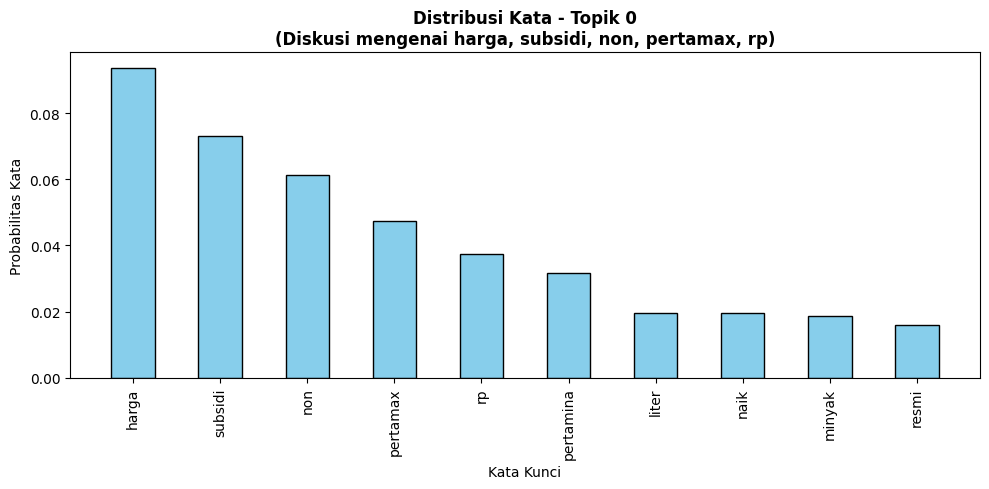

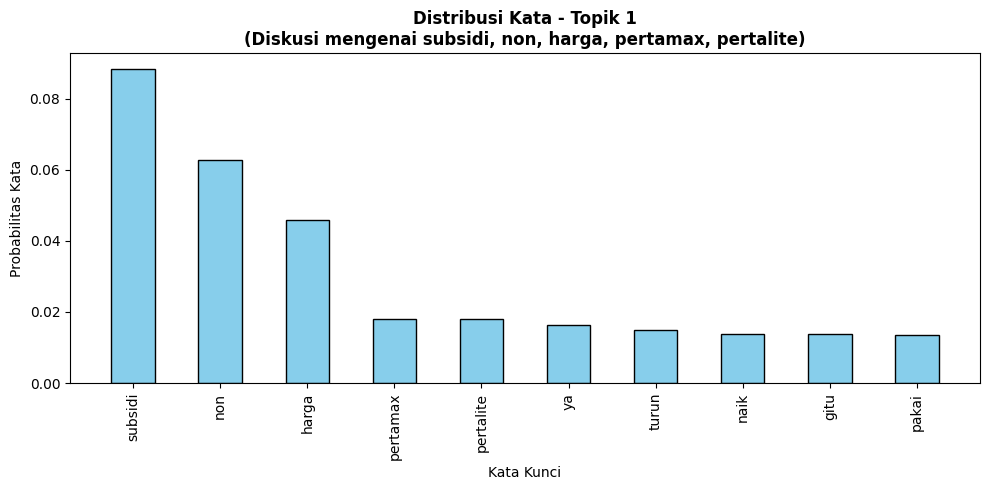

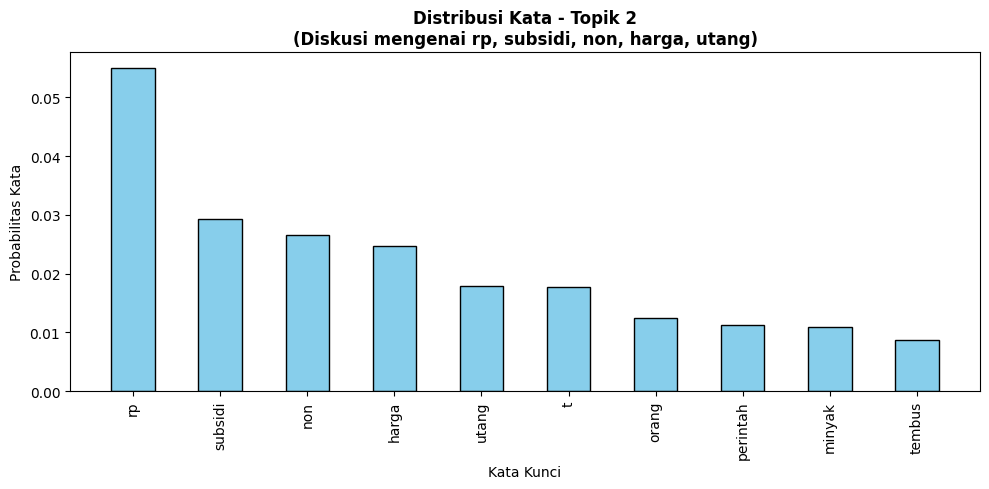

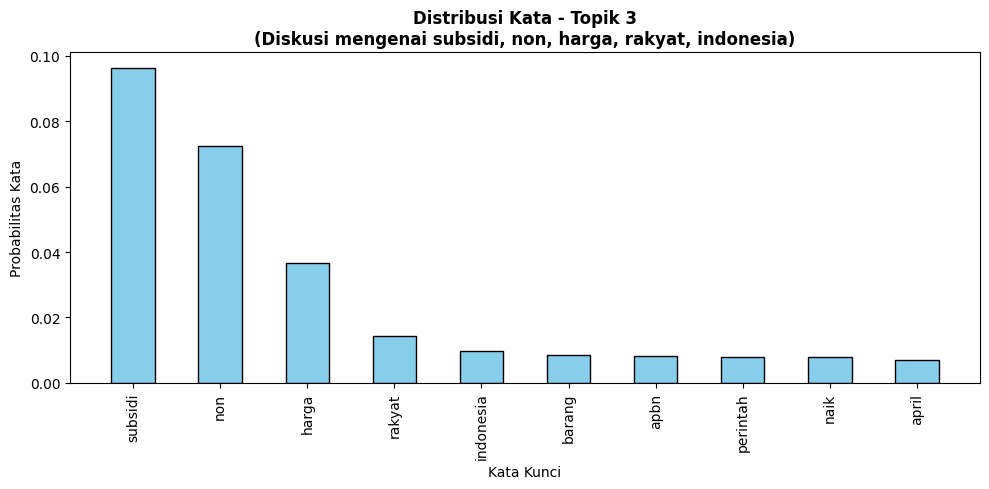


PENAMAAN CLUSTER BERDASARKAN TOPIK DOMINAN

Cluster 0 -> Diskusi mengenai subsidi, non, harga, rakyat, indonesia

Cluster 1 -> Diskusi mengenai harga, subsidi, non, pertamax, rp

Cluster 2 -> Diskusi mengenai subsidi, non, harga, pertamax, pertalite

Cluster 3 -> Diskusi mengenai rp, subsidi, non, harga, utang


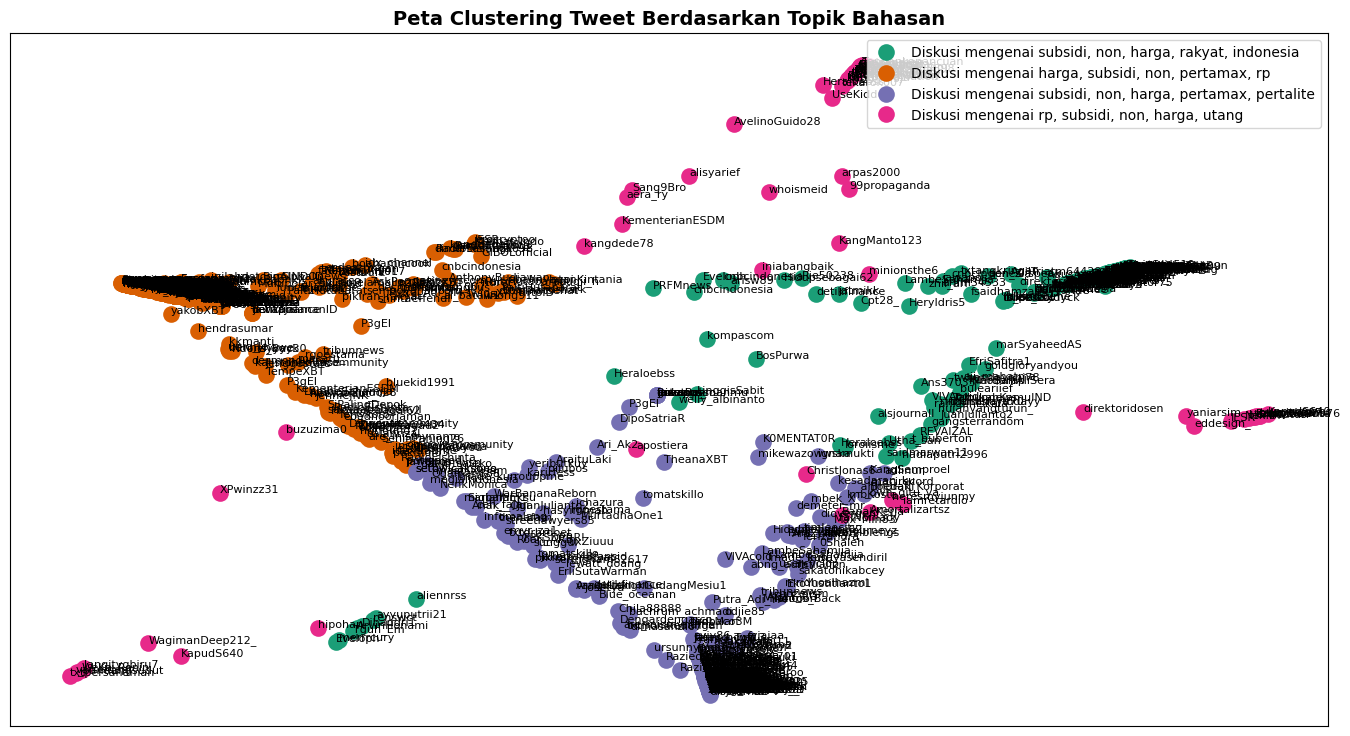


✅ Hasil clustering beserta label topiknya disimpan ke 'hasil_clustering.csv'


In [21]:
tweets_processed = df_preprocess_final['stemmed_text'].apply(lambda x: x.split()).tolist()

print(f"Total dokumen yang akan dimodelkan: {len(tweets_processed)}")

dictionary = Dictionary(tweets_processed)

dictionary.filter_extremes(no_below=2, no_above=0.9)

corpus = [dictionary.doc2bow(tweet) for tweet in tweets_processed]

num_topics = 4

lda = ldamodel.LdaModel(
    corpus,
    num_topics=num_topics,
    id2word=dictionary,
    random_state=1,
    iterations=1000,
    passes=10
)

print("\nModel LDA berhasil dilatih!")

def generate_topic_label(topic_words, top_n=5):

    keywords = [word for word, prob in topic_words[:top_n]]

    return f"Diskusi mengenai {', '.join(keywords)}"


topics_matrix = lda.show_topics(formatted=False, num_words=10)

topic_labels = {}
topic_keywords_dict = {}

print("\n" + "="*60)
print("HASIL IDENTIFIKASI TOPIK (APA YANG DIBAHAS?)")
print("="*60)

for topic_no, topic_words in topics_matrix:

    label = generate_topic_label(topic_words, top_n=5)
    topic_labels[topic_no] = label
    topic_keywords_dict[topic_no] = [word for word, prob in topic_words[:5]]

    print(f"\n▶ Topik {topic_no}: {label}")
    print("   Kata kunci pendukung:")
    for word, prob in topic_words[:10]:
        print(f"     - {word} ({prob:.4f})")

def plot_word_dist_per_topic(topic_no, topics_matrix, topic_label):
    _, topic_words = topics_matrix[topic_no]
    words = [word for word, prob in topic_words[:10]]
    probs = [prob for word, prob in topic_words[:10]]

    ind = np.arange(len(words))
    plt.figure(figsize=(10, 5))
    plt.bar(ind, probs, width=0.5, color='skyblue', edgecolor='black')
    plt.xticks(ind, words, rotation='vertical')
    plt.title(f'Distribusi Kata - Topik {topic_no}\n({topic_label})', fontsize=12, fontweight='bold')
    plt.ylabel('Probabilitas Kata')
    plt.xlabel('Kata Kunci')
    plt.tight_layout()
    plt.show()

for i in range(num_topics):
    plot_word_dist_per_topic(i, topics_matrix, topic_labels[i])

tweet_vectors = []
for tweet in tweets_processed:
    doc_topics = lda.get_document_topics(dictionary.doc2bow(tweet), minimum_probability=0)
    probs = [prob for (_, prob) in doc_topics]
    tweet_vectors.append(probs)
tweet_vectors = np.array(tweet_vectors)

num_clusters = num_topics
km = KMeans(n_clusters=num_clusters, random_state=42)
km.fit(tweet_vectors)

clusters = km.labels_.tolist()

order_centroids = km.cluster_centers_.argsort()[:, ::-1]
cluster_names = {}

print("\n" + "="*60)
print("PENAMAAN CLUSTER BERDASARKAN TOPIK DOMINAN")
print("="*60)

for i in range(num_clusters):
    dominant_topic_idx = order_centroids[i, 0]
    cluster_names[i] = topic_labels[dominant_topic_idx]

    print(f"\nCluster {i} -> {cluster_names[i]}")

mds = MDS(n_components=2, random_state=42)
pos = mds.fit_transform(tweet_vectors)
xs, ys = pos[:, 0], pos[:, 1]

def plot_doc_cluster(xs, ys, clusters, acc_names, cluster_names):
    cluster_colors = {0: '#1b9e77', 1: '#d95f02', 2: '#7570b3', 3: '#e7298a', 4: '#66a61e'}
    df_vis = pd.DataFrame(dict(x=xs, y=ys, label=clusters, acc_names=acc_names))
    groups = df_vis.groupby('label')

    fig, ax = plt.subplots(figsize=(17, 9))
    ax.margins(0.05)

    for name, group in groups:
        ax.plot(group.x, group.y, marker='o', linestyle='', ms=12,
                label=cluster_names[name], color=cluster_colors.get(name, 'black'), mec='none')

    ax.set_aspect('auto')
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax.tick_params(axis='y', which='both', left=False, top=False, labelleft=False)

    ax.legend(numpoints=1, loc='upper right', fontsize=10)

    for i in range(len(df_vis)):
        ax.text(df_vis.iloc[i]['x'], df_vis.iloc[i]['y'], df_vis.iloc[i]['acc_names'], size=8)

    plt.title('Peta Clustering Tweet Berdasarkan Topik Bahasan', fontsize=14, fontweight='bold')
    plt.show()

plot_doc_cluster(xs, ys, clusters, acc_names, cluster_names)

df_cluster = pd.DataFrame({
    'username': acc_names,
    'tweet_raw': df['full_text'],
    'cluster': clusters,
    'topik_dominan': [cluster_names[c] for c in clusters]
})

df_cluster.to_csv('hasil_clustering.csv', index=False)
print("\n✅ Hasil clustering beserta label topiknya disimpan ke 'hasil_clustering.csv'")

# **3. NER (NAMED ENTITY RECOGNITION)**

In [24]:
# 1. DEFINISI KAMUS DOMAIN (Domain Dictionary)
# Daftar nama tokoh yang sering muncul di berita ini
DOMAIN_PERSONS = [
    'prabowo', 'bahlil', 'purbaya', 'said iqbal', 'firre an suprapto',
    'fifi aleyda yahya', 'jokowi', 'tirta', 'amien rais'
]

# Daftar instansi/lembaga
DOMAIN_ORGS = [
    'pertamina', 'apbn', 'komisi xii dpr', 'kementerian esdm',
    'kementerian komunikasi dan digital', 'kementerian keuangan',
    'kspi', 'hmi', 'pln', 'dpr', 'mk', 'imf'
]

# Daftar lokasi (Negara/Kota yang relevan dengan isu BBM global/domestik)
DOMAIN_LOCS = [
    'indonesia', 'jakarta', 'amerika', 'iran', 'timur tengah',
    'sumatera', 'jawa', 'aceh', 'sumbar', 'bandung'
]

# Daftar produk BBM dan Energi
DOMAIN_PRODUCTS = [
    'pertamax', 'pertalite', 'solar', 'dexlite', 'pertamax green',
    'pertamax turbo', 'lpg', 'bbm', 'minyak mentah', 'bensin'
]

# Kata-kata yang menjadi penanda entitas di sebelah kanannya

# Penanda Person (PPRE, PTIT)
PERSON_TITLES = r'(?:Pak|Bu|Prof\. |Dr\. |Ir\. |Drs\. |Presiden|Menkeu|Menteri|Jubir|Ketua|Direktur|VP|Wakil)\s+'
# Penanda Organization (OPRE)
ORG_PREFIXES = r'(?:PT\. |Kementerian|Universitas|Badan)\s+'
# Penanda Location (LOPP - Prepositions)
LOC_PREPOSITIONS = r'(?:di|ke|dari)\s+'


# 3. FUNGSI NER BERBASIS ATURAN (Rule Assignment)
# Menggabungkan Fitur Kontekstual, Morfologis, dan Kamus

def extract_entities_budi(text):
    """
    Fungsi utama untuk mengekstrak entitas.
    Mengembalikan list of tuples: (entity_text, entity_label)
    """
    entities = []

    # --- ATURAN 1: FITUR MORFOLOGIS UNTUK UANG (MONEY) ---
    # Mencari pola angka yang diawali Rp, US$, atau $
    money_patterns = re.findall(r'(Rp\s*[\d.,]+|US\$\s*[\d.,]+|\$\s*[\d.,]+)', text, re.IGNORECASE)
    for m in money_patterns:
        entities.append((m.replace(' ', ''), 'MONEY')) # Bersihkan spasi di Rp 16.250

    # --- ATURAN 2: FITUR KONTEKSTUAL (CONTEXTUAL RULES) ---

    # Rule 2.1: Person Context (Jika ada judul/sebutan, kata selanjutnya adalah Person)
    # Contoh: "Menteri Bahlil" -> Bahlil adalah PERSON
    person_ctx = re.findall(PERSON_TITLES + r'([A-Z][a-z]+(?:\s+[A-Z][a-z]+)*)', text)
    for p in person_ctx:
        entities.append((p, 'PERSON'))

    # Rule 2.2: Organization Context (Jika ada awalan instansi, kata selanjutnya adalah Org)
    # Contoh: "PT Pertamina" -> Pertamina adalah ORGANIZATION
    org_ctx = re.findall(ORG_PREFIXES + r'([A-Za-z]+(?:\s+[A-Za-z]+)*)', text)
    for o in org_ctx:
        entities.append((o, 'ORGANIZATION'))

    # Rule 2.3: Location Context (Jika ada preposisi tempat, kata selanjutnya adalah Loc)
    # Contoh: "di Jakarta" -> Jakarta adalah LOCATION
    loc_ctx = re.findall(LOC_PREPOSITIONS + r'([A-Z][a-z]+(?:\s+[A-Z][a-z]+)*)', text)
    for l in loc_ctx:
        # Filter agar tidak menangkap kata benda biasa setelah 'di/ke/dari'
        if l.lower() not in ['tengah', 'atas', 'bawah', 'sini', 'sana', 'mana', 'dunia']:
            entities.append((l, 'LOCATION'))

    # --- ATURAN 3: KAMUS DOMAIN EXACT MATCH (Knowledge Engineering) ---
    # Mencari kecocokan persis kata dalam teks dengan kamus yang sudah kita buat di atas.

    # 3.1 Cek Produk (BBM)
    for prod in DOMAIN_PRODUCTS:
        if re.search(r'\b' + re.escape(prod) + r'\b', text, re.IGNORECASE):
            entities.append((prod.title(), 'PRODUCT'))

    # 3.2 Cek Lokasi spesifik
    for loc in DOMAIN_LOCS:
        if re.search(r'\b' + re.escape(loc) + r'\b', text, re.IGNORECASE):
            entities.append((loc.title(), 'LOCATION'))

    # 3.3 Cek Organisasi spesifik
    for org in DOMAIN_ORGS:
        if re.search(r'\b' + re.escape(org) + r'\b', text, re.IGNORECASE):
            entities.append((org.title(), 'ORGANIZATION'))

    # 3.4 Cek Tokoh/Person spesifik
    for person in DOMAIN_PERSONS:
        if re.search(r'\b' + re.escape(person) + r'\b', text, re.IGNORECASE):
            entities.append((person.title(), 'PERSON'))

    # --- ATURAN 4: MORFOLOGIS ACRONYM (UpperCase Features - Tabel 2 Budi et al.) ---
    # Mencari kata yang SELURUHNYA HURUF KAPITAL (Panjang > 1)
    # Contoh: "APBN", "PLN", "DPR", "BBM", "LPG"
    isolated_upper = re.findall(r'(?<!\w)([A-Z]{2,})(?!\w)', text)
    for u in isolated_upper:
        if u in ['BBM', 'LPG', 'SPBU']: # Penyesuaian domain
            entities.append((u, 'PRODUCT'))
        elif u not in ['RT', 'AMP']:    # Bukan retweet tag
            entities.append((u, 'ORGANIZATION'))

    return entities


# 4. EKSEKUSI NER PADA SELURUH DATASET

# Ambil teks asli dari dataframe awal
tweets_raw = df['full_text'].tolist()
acc_names = df['username'].tolist()

ner_results = []

print("Memproses Rule-Based NER (Budi et al. 2005)...\n")

for i, tweet in enumerate(tweets_raw):
    # Panggil fungsi NER
    found_entities = extract_entities_budi(tweet)

    # Simpan hasilnya jika ada entitas yang ditemukan
    for entity_text, entity_label in found_entities:
        ner_results.append({
            'username': acc_names[i],
            'entity': entity_text,
            'label': entity_label,
            'kalimat_contoh': tweet[:100] + "..." # Untuk bukti tracing
        })

# Konversi ke DataFrame
df_ner = pd.DataFrame(ner_results)

# 5. PENGHILANGAN DUPLIKAT (DEDUPLICATION)
# Budi et al. menekankan penggabungan entitas yang sama dalam satu kalimat

df_ner = df_ner.drop_duplicates(subset=['username', 'entity', 'label'])


# 6. OUTPUT DAN ANALISIS HASIL

print(f"Total entitas berhasil diekstrak: {len(df_ner)}")
print("\nDistribusi Label Entitas:")
print(df_ner['label'].value_counts())

print("\n" + "="*60)
print("CONTOH ENTITAS YANG BERHASIL DIKENALI PER KATEGORI:")
print("="*60)

for label in df_ner['label'].unique():
    print(f"\n▶ {label}:")
    top_entities = df_ner[df_ner['label']==label]['entity'].value_counts().head(5)
    for entity, count in top_entities.items():
        print(f"   - {entity} (muncul {count} kali)")

# Tampilkan contoh bagaimana sistem membaca kalimat
print("\n" + "="*60)
print("CONTOH PROSES TRACING (CARA KERJA MESIN):")
print("="*60)
sample_idx = 2 # Index tweet ke-3 (biasanya ada banyak entitas)
sample_tweet = tweets_raw[sample_idx]
sample_entities = extract_entities_budi(sample_tweet)

print(f"\nTeks Asli:\n'{sample_tweet}'\n")
print("Entitas yang ditemukan:")
for ent, lab in sample_entities:
    print(f" - [#{lab}] {ent}")


# 7. SIMPAN HASIL KE CSV
df_ner.to_csv('hasil_ner_rulebase.csv', index=False)
print("\n✅ Hasil NER Rule-Based disimpan ke 'hasil_ner_rulebase.csv'")

Memproses Rule-Based NER (Budi et al. 2005)...

Total entitas berhasil diekstrak: 3203

Distribusi Label Entitas:
label
PRODUCT         1534
ORGANIZATION     915
LOCATION         356
MONEY            310
PERSON            88
Name: count, dtype: int64

CONTOH ENTITAS YANG BERHASIL DIKENALI PER KATEGORI:

▶ LOCATION:
   - Rp (muncul 57 kali)
   - Indonesia (muncul 45 kali)
   - Naik (muncul 27 kali)
   - Pertamax (muncul 20 kali)
   - Iran (muncul 19 kali)

▶ PRODUCT:
   - Bbm (muncul 551 kali)
   - BBM (muncul 443 kali)
   - Pertamax (muncul 173 kali)
   - Pertalite (muncul 95 kali)
   - Pertamax Turbo (muncul 49 kali)

▶ PERSON:
   - Prabowo (muncul 21 kali)
   - Bahlil (muncul 20 kali)
   - Purbaya (muncul 9 kali)
   - Energi (muncul 6 kali)
   - Jokowi (muncul 4 kali)

▶ MONEY:
   - Rp16.250 (muncul 40 kali)
   - Rp12.300 (muncul 24 kali)
   - Rp17.000 (muncul 18 kali)
   - Rp12.900 (muncul 15 kali)
   - Rp10.000 (muncul 10 kali)

▶ ORGANIZATION:
   - Pertamina (muncul 116 kali)
   -